In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import shap

In [17]:
#Data Specs
data = pd.read_csv("../../data/marketdata.csv")
print(len(data))

minority_class = (data['market_crisis']>0).sum()
majority_class = (data['market_crisis']==0).sum()
imbalance = minority_class/len(data)
print(minority_class)
print(majority_class)
print(imbalance)
print(data.columns.tolist())


4701
434
4267
0.09232078281216763
['Date', 'SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg', 'market_crisis']


In [18]:
#Train Test Split
X = data[['SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg']]
y = data['market_crisis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

print(len(X_train), len(X_test))

3760 941


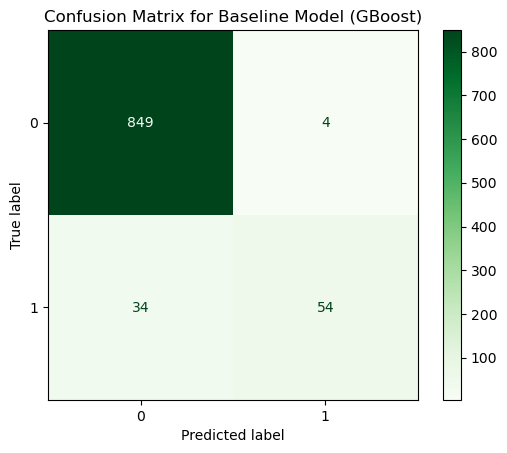

Train Acc:0.9781914893617021
Test Acc:0.9596174282678002
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       853
           1       0.93      0.61      0.74        88

    accuracy                           0.96       941
   macro avg       0.95      0.80      0.86       941
weighted avg       0.96      0.96      0.96       941



In [19]:
#Baseline Model

baseline = GradientBoostingClassifier(random_state=101)
baseline.fit(X_train, y_train)

train_acc = baseline.score(X_train, y_train)
test_acc = baseline.score(X_test, y_test)
base_pred = baseline.predict(X_test)

confusion = confusion_matrix(y_test, base_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Greens")
plt.title("Confusion Matrix for Baseline Model (GBoost)")
plt.savefig("../visualizations/GB_ML/baseline_matrix_RF.png")
plt.show()

print(f"Train Acc:{train_acc}")
print(f"Test Acc:{test_acc}")
print(classification_report(y_test, base_pred))

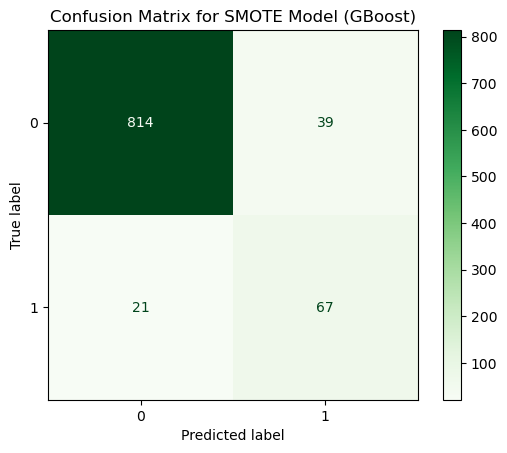

Train Acc:0.9443468072642062
Test Acc:0.9362380446333688
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       853
           1       0.63      0.76      0.69        88

    accuracy                           0.94       941
   macro avg       0.80      0.86      0.83       941
weighted avg       0.94      0.94      0.94       941



In [20]:
#SMOTE model

X_sm_gb, y_sm_gb = SMOTE(random_state=101).fit_resample(X_train, y_train)
gb_smote = GradientBoostingClassifier(random_state=101)
gb_smote.fit(X_sm_gb, y_sm_gb)

sm_train_acc = gb_smote.score(X_sm_gb, y_sm_gb)
sm_test_acc = gb_smote.score(X_test, y_test)
gb_smote_pred = gb_smote.predict(X_test)

confusion = confusion_matrix(y_test, gb_smote_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Greens")
plt.title("Confusion Matrix for SMOTE Model (GBoost)")
plt.savefig("../visualizations/GB_ML/SMOTE_matrix_RF.png")
plt.show()

print(f"Train Acc:{sm_train_acc}")
print(f"Test Acc:{sm_test_acc}")
print(classification_report(y_test, gb_smote_pred))

In [21]:
#Grid Search for SMOTE GB Model

pipeline = Pipeline([
    ('smote', SMOTE(random_state=101)),
    ('gb', GradientBoostingClassifier(random_state=101))
])

param_grid = {
    'gb__n_estimators': [100, 200, 300],
    'gb__max_depth': [3, 5, 7],
    'gb__learning_rate': [0.01, 0.1, 0.2],
    'gb__min_samples_leaf': [3, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best recall: {grid.best_score_}")

Best params: {'gb__learning_rate': 0.2, 'gb__max_depth': 5, 'gb__min_samples_leaf': 5, 'gb__n_estimators': 300}
Best recall: 0.8036438923395446


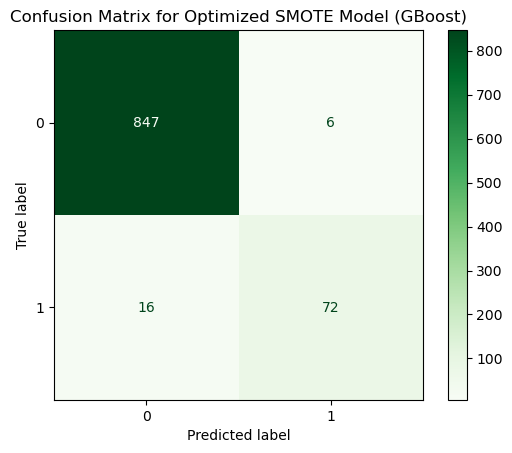

Train Acc:1.0
Test Acc:0.9766206163655685
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       853
           1       0.92      0.82      0.87        88

    accuracy                           0.98       941
   macro avg       0.95      0.91      0.93       941
weighted avg       0.98      0.98      0.98       941



In [22]:
#Best GB Model
best_gb = GradientBoostingClassifier(learning_rate=0.2, max_depth=5, min_samples_leaf=5, n_estimators=300, random_state=101)
best_gb.fit(X_sm_gb, y_sm_gb)

best_train = best_gb.score(X_sm_gb, y_sm_gb)
best_test = best_gb.score(X_test, y_test)
best_gb_pred = best_gb.predict(X_test)

confusion = confusion_matrix(y_test, best_gb_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Greens")
plt.title("Confusion Matrix for Optimized SMOTE Model (GBoost)")
plt.savefig("../visualizations/GB_ML/op_SMOTE_matrix_RF.png")
plt.show()

print(f"Train Acc:{best_train}")
print(f"Test Acc:{best_test}")
print(classification_report(y_test, best_gb_pred))

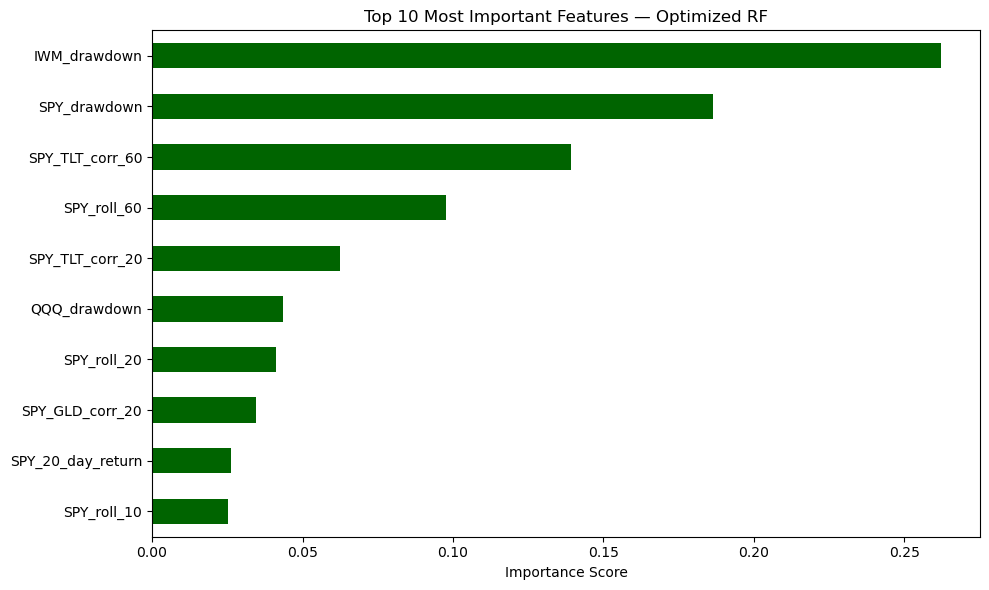

In [23]:
importances = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_10 = importances.head(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='darkgreen')
plt.title("Top 10 Most Important Features — Optimized RF")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../visualizations/GB_ML/feature_importance_top10_GB.png")
plt.show()

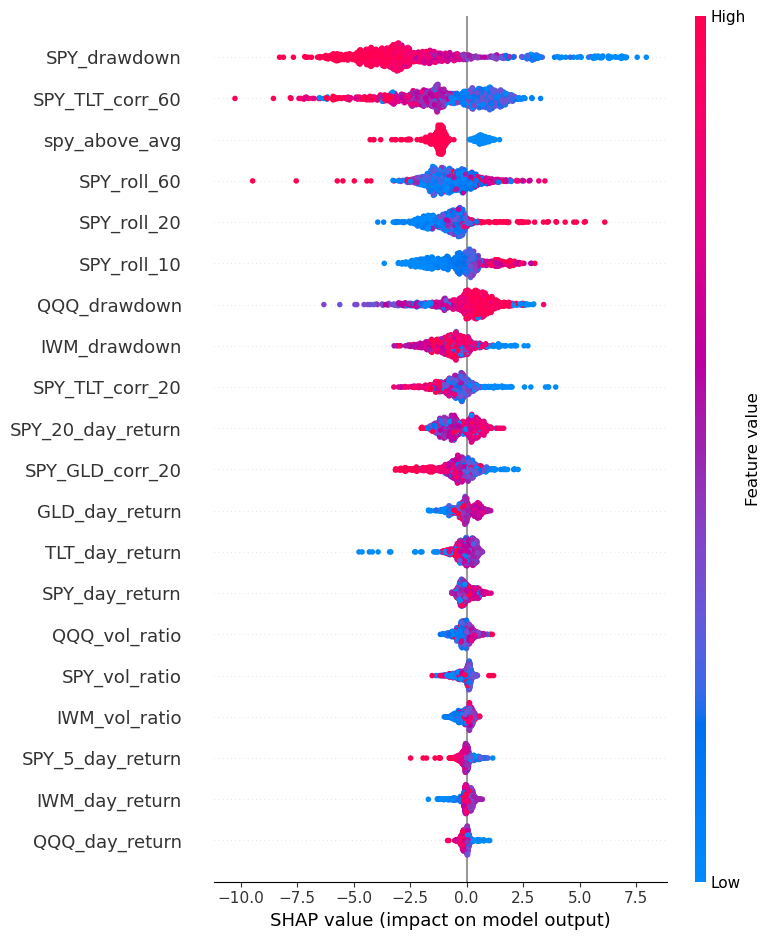

In [24]:
explainer = shap.TreeExplainer(best_gb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=False)
plt.savefig("../visualizations/GB_ML/GB_SHAP.png")
plt.show()


In [ ]:
#Reduced Model Using Feature Importance

redX = data[['IWM_drawdown', 'SPY_drawdown', 'SPY_TLT_corr_60', 'SPY_roll_60', 'QQQ_drawdown']]

rX_train, rX_test, y_train, y_test = train_test_split(redX, y, test_size = 0.2, random_state=101)

confusion = confusion_matrix(y_test, rX_test)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Greens")
plt.title("Confusion Matrix for Optimized SMOTE Model (GBoost)")
plt.savefig("../visualizations/GB_ML/op_SMOTE_matrix_RF.png")
plt.show()


In [ ]:
#Optimized reduced model using Grid Search

rpipeline = Pipeline([
    ('smote', SMOTE(random_state=101)),
    ('gb', GradientBoostingClassifier(random_state=101))
])

param_grid = {
    'gb__n_estimators': [100, 200, 300],
    'gb__max_depth': [3, 5, 7],
    'gb__learning_rate': [0.01, 0.1, 0.2],
    'gb__min_samples_leaf': [3, 5]
}

grid = GridSearchCV(
    rpipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(rX_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best recall: {grid.best_score_}")

Best params: {'gb__learning_rate': 0.2, 'gb__max_depth': 5, 'gb__min_samples_leaf': 5, 'gb__n_estimators': 300}
Best recall: 0.8324223602484471


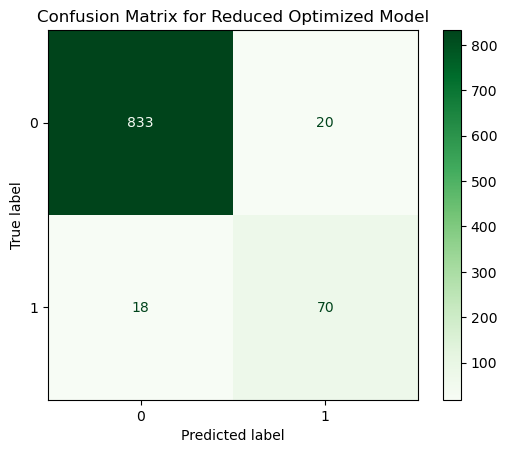

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       853
           1       0.78      0.80      0.79        88

    accuracy                           0.96       941
   macro avg       0.88      0.89      0.88       941
weighted avg       0.96      0.96      0.96       941



In [15]:
#Optimzed Reduced Model
rX_sm_gb, ry_sm_gb = SMOTE(random_state=101).fit_resample(rX_train, y_train)
redMod = GradientBoostingClassifier(learning_rate=0.2, max_depth=5, min_samples_leaf=5, n_estimators=300, random_state=101)
redMod.fit(rX_sm_gb, ry_sm_gb)
redPreds = redMod.predict(rX_test)


confusion = confusion_matrix(y_test, redPreds)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Greens")
plt.title("Confusion Matrix for Reduced Optimized Model")
plt.savefig("../visualizations/GB_ML/redop_matrix_RF.png")
plt.show()


print(classification_report(y_test, redPreds))



In [25]:
import pickle
import os

os.makedirs("best_mod", exist_ok=True)

with open("best_mod/best_model.pkl", "rb") as f:
    test_model = pickle.load(f)

print(type(test_model))
print(hasattr(test_model, 'predict_proba'))
print(best_gb.feature_names_in_)

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
True
['SPY_roll_10' 'SPY_roll_20' 'SPY_roll_60' 'SPY_day_return'
 'SPY_5_day_return' 'SPY_20_day_return' 'QQQ_day_return' 'IWM_day_return'
 'TLT_day_return' 'GLD_day_return' 'SPY_drawdown' 'QQQ_drawdown'
 'IWM_drawdown' 'SPY_TLT_corr_20' 'SPY_TLT_corr_60' 'SPY_GLD_corr_20'
 'SPY_vol_ratio' 'QQQ_vol_ratio' 'IWM_vol_ratio' 'spy_above_avg']


In [ ]:
import numpy as np
from sklearn.calibration import CalibratedClassifierCV

y = data['market_crisis']
features = ['Vix', 'VIX_roll_10', 'VIX_roll_20', 'VIX_day_change', 'VIX_sd',
            'SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return',
            'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return',
            'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown',
            'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60',
            'SPY_GLD_corr_20', 'SPY_VIX_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio',
            'IWM_vol_ratio', 'spy_above_avg']

calibrated_model = CalibratedClassifierCV(best_gb, cv=5, method='isotonic')
calibrated_model.fit(data[features].values, y)
probs = calibrated_model.predict_proba(data[features].values)[:, 1]


FileNotFoundError: [Errno 2] No such file or directory: '../analysis/models/best_mod/probs.npy'

In [26]:
np.save('best_mod/probs.npy', probs)